In [1]:
!pip install -q roboflow
!pip install -q ultralytics
!pip install -q opencv-python matplotlib seaborn tqdm pyyaml
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from roboflow import Roboflow
from ultralytics import YOLO

print("✅ All libraries installed and imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 72.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ All libraries installed and imported successfully.


In [2]:
rf = Roboflow(api_key="yoDD8EsZDtmxJZTG5kMB")

project = rf.workspace("usmanchaudhry622-gmail-com").project("traffic-and-road-signs")
version = project.version(1)

dataset = version.download("yolov8")

print("✅ Dataset downloaded successfully.")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-and-Road-Signs-1 in yolov8:: 100%|██████████| 20012/20012 [00:02<00:00, 7911.56it/s] 

✅ Dataset downloaded successfully.


📁 Dataset directory: /content/Traffic-and-Road-Signs-1

📄 data.yaml contents:
names: ['-Road narrows on right', '50 mph speed limit', 'Attention Please-', 'Beware of children', 'CYCLE ROUTE AHEAD WARNING', 'Dangerous Left Curve Ahead', 'Dangerous Rright Curve Ahead', 'End of all speed and passing limits', 'Give Way', 'Go Straight or Turn Right', 'Go straight or turn left', 'Keep-Left', 'Keep-Right', 'Left Zig Zag Traffic', 'No Entry', 'No_Over_Taking', 'Overtaking by trucks is prohibited', 'Pedestrian Crossing', 'Round-About', 'Slippery Road Ahead', 'Speed Limit 20 KMPh', 'Speed Limit 30 KMPh', 'Stop_Sign', 'Straight Ahead Only', 'Traffic_signal', 'Truck traffic is prohibited', 'Turn left ahead', 'Turn right ahead', 'Uneven Road']
nc: 29
roboflow: {'license': 'CC BY 4.0', 'project': 'traffic-and-road-signs', 'url': 'https://universe.roboflow.com/usmanchaudhry622-gmail-com/traffic-and-road-signs/dataset/1', 'version': 1, 'workspace': 'usmanchaudhry622-gmail-com'}
test: ../test/images
tr

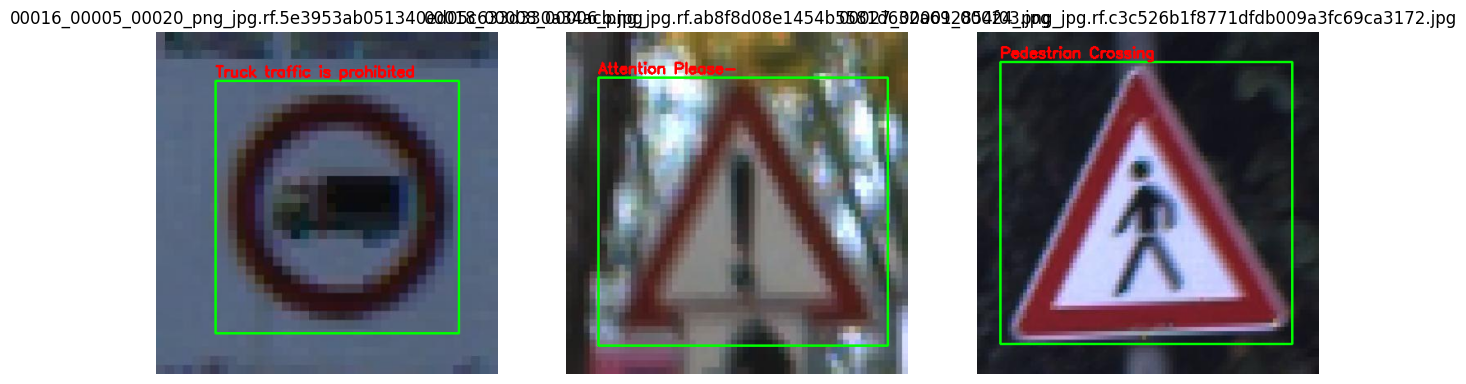

In [3]:
import yaml
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path

DATASET_DIR = Path(dataset.location)

print("📁 Dataset directory:", DATASET_DIR)

yaml_path = DATASET_DIR / "data.yaml"

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print("\n📄 data.yaml contents:")
for k, v in data_yaml.items():
    print(f"{k}: {v}")


def count_images(split):
    return len(list((DATASET_DIR / split / "images").glob("*")))

print("\n📊 Dataset Statistics:")
print(f"Train images: {count_images('train')}")
print(f"Valid images: {count_images('valid')}")
print(f"Test images : {count_images('test')}")
print(f"Number of classes: {data_yaml['nc']}")


def visualize_samples(split="train", num_samples=3):
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"

    images = list(image_dir.glob("*"))
    samples = random.sample(images, num_samples)

    plt.figure(figsize=(15, 5))

    for i, img_path in enumerate(samples):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape
        label_path = label_dir / f"{img_path.stem}.txt"

        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    cls, x, y, bw, bh = map(float, line.split())

                    x1 = int((x - bw / 2) * w)
                    y1 = int((y - bh / 2) * h)
                    x2 = int((x + bw / 2) * w)
                    y2 = int((y + bh / 2) * h)

                    class_name = data_yaml["names"][int(cls)]
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(
                        img,
                        class_name,
                        (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (255, 0, 0),
                        2
                    )

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.show()

visualize_samples(split="train", num_samples=3)

In [4]:
from ultralytics import YOLO

# Load the best performing model that was downloaded
model = YOLO("/content/best (1).pt")

print("✅ Model loaded successfully from /content/best (1).pt")

✅ Model loaded successfully from /content/best (1).pt


In [5]:
import yaml
from pathlib import Path
from tqdm import tqdm

LABEL_SPLITS = ["train", "valid", "test"]

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

old_names = data_yaml["names"]
print("🔎 Original classes:", old_names)

SPECIFIC_SPEED_LIMIT_CLASSES = ["50 mph speed limit", "Speed Limit 20 KMPh", "Speed Limit 30 KMPh"]
MERGED_CLASS_NAME = "speed_limit"

# Check if the dataset has already been processed to a single 'speed_limit' class
if old_names == [MERGED_CLASS_NAME]:
    print(f"\n✅ Dataset already processed to a single '{MERGED_CLASS_NAME}' class by a previous step. Skipping further merging operations in this cell.")
else:
    # Identify speed limit class indices from the original classes that are to be merged
    SPEED_LIMIT_CLASSES_INDICES = set()
    for class_name in SPECIFIC_SPEED_LIMIT_CLASSES:
        if class_name in old_names:
            SPEED_LIMIT_CLASSES_INDICES.add(old_names.index(class_name))
        else:
            print(f"Warning: Class '{class_name}' not found in original classes. It will not be merged from this list.")

    # If the general 'speed_limit' class already exists in old_names and is not one of the specific ones to be removed,
    # it should also be mapped to the single merged 'speed_limit' class.
    if MERGED_CLASS_NAME in old_names and old_names.index(MERGED_CLASS_NAME) not in SPEED_LIMIT_CLASSES_INDICES:
        SPEED_LIMIT_CLASSES_INDICES.add(old_names.index(MERGED_CLASS_NAME))

    print(f"🔎 Speed limit class indices to be merged: {SPEED_LIMIT_CLASSES_INDICES}")

    # Build new class list: remove specific speed limits and ensure only one 'speed_limit' class exists
    non_speed_names = [n for n in old_names if n not in SPECIFIC_SPEED_LIMIT_CLASSES and n != MERGED_CLASS_NAME]
    new_names = non_speed_names + [MERGED_CLASS_NAME]  # The merged class always goes at the end

    # Build a mapping: old class id → new class id
    old_to_new = {}
    merged_class_new_idx = len(new_names) - 1

    for old_idx, name in enumerate(old_names):
        if old_idx in SPEED_LIMIT_CLASSES_INDICES:
            old_to_new[old_idx] = merged_class_new_idx  # Map to the new 'speed_limit' class
        else:
            # For other non-speed-limit classes, find their new index
            try:
                new_idx = new_names.index(name)
                old_to_new[old_idx] = new_idx
            except ValueError:
                print(f"Warning: Class '{name}' (old index {old_idx}) not found in new_names. This class will be excluded from labels.")

    print(f"\n📋 Class mapping (old → new):")
    for old_idx, new_idx in old_to_new.items():
        # Only print mappings for classes that are actually included in the new list
        if old_idx in old_to_new:
            print(f"  [{old_idx}] {old_names[old_idx]} → [{new_idx}] {new_names[new_idx]}")

    # Rewrite all label files
    for split in LABEL_SPLITS:
        label_dir = DATASET_DIR / split / "labels"
        label_files = list(label_dir.glob("*.txt"))
        print(f"\n✏️ Processing {split} ({len(label_files)} files)")

        for label_file in tqdm(label_files):
            new_lines = []
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue  # Skip malformed lines
                    old_cls = int(parts[0])
                    new_cls = old_to_new.get(old_cls)  # Get new class, None if not found
                    if new_cls is not None:
                        new_lines.append(f"{new_cls} {parts[1]} {parts[2]} {parts[3]} {parts[4]}\n")
                    else:
                        print(f"Warning: Label for old class ID {old_cls} in {label_file.name} is being dropped as it's not in the new mapping.")

            with open(label_file, "w") as f:
                f.writelines(new_lines)

    # Update and save YAML
    data_yaml["nc"] = len(new_names)
    data_yaml["names"] = new_names
    with open(yaml_path, "w") as f:
        yaml.safe_dump(data_yaml, f, sort_keys=False)

    print(f"\n✅ Merging complete — {len(new_names)} classes total")
    print(f"✅ New class list: {new_names}")

🔎 Original classes: ['-Road narrows on right', '50 mph speed limit', 'Attention Please-', 'Beware of children', 'CYCLE ROUTE AHEAD WARNING', 'Dangerous Left Curve Ahead', 'Dangerous Rright Curve Ahead', 'End of all speed and passing limits', 'Give Way', 'Go Straight or Turn Right', 'Go straight or turn left', 'Keep-Left', 'Keep-Right', 'Left Zig Zag Traffic', 'No Entry', 'No_Over_Taking', 'Overtaking by trucks is prohibited', 'Pedestrian Crossing', 'Round-About', 'Slippery Road Ahead', 'Speed Limit 20 KMPh', 'Speed Limit 30 KMPh', 'Stop_Sign', 'Straight Ahead Only', 'Traffic_signal', 'Truck traffic is prohibited', 'Turn left ahead', 'Turn right ahead', 'Uneven Road']
🔎 Speed limit class indices to be merged: {1, 20, 21}

📋 Class mapping (old → new):
  [0] -Road narrows on right → [0] -Road narrows on right
  [1] 50 mph speed limit → [26] speed_limit
  [2] Attention Please- → [1] Attention Please-
  [3] Beware of children → [2] Beware of children
  [4] CYCLE ROUTE AHEAD WARNING → [3] CY

100%|██████████| 7092/7092 [00:00<00:00, 9176.13it/s]



✏️ Processing valid (1884 files)


100%|██████████| 1884/1884 [00:00<00:00, 9493.37it/s]



✏️ Processing test (1024 files)


100%|██████████| 1024/1024 [00:00<00:00, 9387.15it/s]


✅ Merging complete — 27 classes total
✅ New class list: ['-Road narrows on right', 'Attention Please-', 'Beware of children', 'CYCLE ROUTE AHEAD WARNING', 'Dangerous Left Curve Ahead', 'Dangerous Rright Curve Ahead', 'End of all speed and passing limits', 'Give Way', 'Go Straight or Turn Right', 'Go straight or turn left', 'Keep-Left', 'Keep-Right', 'Left Zig Zag Traffic', 'No Entry', 'No_Over_Taking', 'Overtaking by trucks is prohibited', 'Pedestrian Crossing', 'Round-About', 'Slippery Road Ahead', 'Stop_Sign', 'Straight Ahead Only', 'Traffic_signal', 'Truck traffic is prohibited', 'Turn left ahead', 'Turn right ahead', 'Uneven Road', 'speed_limit']


In [6]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted")

Mounted at /content/drive
✅ Google Drive mounted


In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATASET_DIR / "data.yaml"),
    epochs=85,
    patience=15,
    imgsz=640,
    batch=16,
    device=0,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,              # final lr = lr0 * lrf, cosine decay to 1% of initial
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,       # gradual warmup, prevents early instability
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # Augmentations
    hsv_h=0.02,            # slight hue — signs have strict colors, keep low
    hsv_s=0.75,            # saturation — handles different lighting
    hsv_v=0.45,            # brightness — day/night/shadow robustness
    degrees=10.0,          # rotation — signs are sometimes tilted in the wild
    translate=0.1,         # position shift
    scale=0.6,             # zoom — signs appear at many distances
    shear=2.0,
    perspective=0.0001,    # subtle 3D warp — signs captured at angles
    mosaic=1.0,            # 4-image mosaic, great for small object detection
    mixup=0.15,            # blends two images, helps generalization
    copy_paste=0.1,        # copies objects across images, helps rare classes
    close_mosaic=10,       # disables mosaic in last 10 epochs for stable convergence
    fliplr=0.0,            # CRITICAL: keep at 0 — flipping corrupts directional signs

    # Save directly to Drive
    project="/content/drive/MyDrive/traffic_signs",
    name="yolov8n_27class",
    exist_ok=True
)

print("✅ Training complete — best.pt saved to Google Drive")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic-and-Road-Signs-1/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=85, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.75, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_27class, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, 

In [8]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 31.1 MB/s eta 0:00:00


In [32]:
from ultralytics import YOLO
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

detector = YOLO("/content/drive/MyDrive/traffic_signs/yolov8n_27class/weights/best.pt")
speed_detector = YOLO("/content/best (1).pt")
reader = easyocr.Reader(['en'], gpu=False)

VALID_LIMITS = {"20", "30", "50"}

print("✅ Both models and OCR reader loaded")

✅ Both models and OCR reader loaded


In [33]:
def read_speed_limit(crop):
    """Tries multiple preprocessing strategies, returns first valid result."""

    VALID_LIMITS = {"20", "30", "50"}
    CONFUSION_MAP = {
        "80": "30", "28": "20", "29": "20",
        "59": "50", "56": "50", "8": "30",
        "3": "30", "2": "20", "5": "50",
    }

    crop_resized = cv2.resize(crop, (128, 128))
    gray = cv2.cvtColor(crop_resized, cv2.COLOR_BGR2GRAY)

    # Generate multiple versions to try
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)

    _, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, otsu_inv = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    clahe2 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(4, 4))
    enhanced2 = clahe2.apply(gray)

    strategies = [denoised, gray, otsu, otsu_inv, enhanced2]

    all_results = []

    for version in strategies:
        results = reader.readtext(version, allowlist='0123456789', detail=1)
        for (_, text, confidence) in results:
            cleaned = text.strip().replace(" ", "")

            # First pass — exact match
            if cleaned in VALID_LIMITS and confidence > 0.3:
                return cleaned

            # Collect for confusion map pass
            all_results.append((cleaned, confidence))

    # Second pass — confusion map over all collected results
    for (cleaned, confidence) in all_results:
        if cleaned in CONFUSION_MAP and confidence > 0.3:
            print(f"⚠️ OCR confusion corrected: '{cleaned}' → '{CONFUSION_MAP[cleaned]}'")
            return CONFUSION_MAP[cleaned]

    return None


def run_pipeline(image_path):
    """Full detection + OCR pipeline on a single image."""
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"❌ Could not read image: {image_path}")
        return

    output = img.copy()
    h, w = img.shape[:2]

    det_results = detector(str(image_path), conf=0.4, verbose=False)[0]

    for box in det_results.boxes:
        cls_id = int(box.cls)
        cls_name = detector.names[cls_id]
        conf = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if cls_name == "speed_limit":
            pad = 5
            x1c = max(0, x1 - pad)
            y1c = max(0, y1 - pad)
            x2c = min(w, x2 + pad)
            y2c = min(h, y2 + pad)
            crop = img[y1c:y2c, x1c:x2c]

            limit = read_speed_limit(crop)
            label = f"speed_limit: {limit} km/h" if limit else "speed_limit: ?"
            color = (0, 200, 0) if limit else (0, 165, 255)
        else:
            label = f"{cls_name} {conf:.2f}"
            color = (255, 100, 0)

        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(output, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(output, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(Path(image_path).name)
    plt.tight_layout()
    plt.show()

    return output

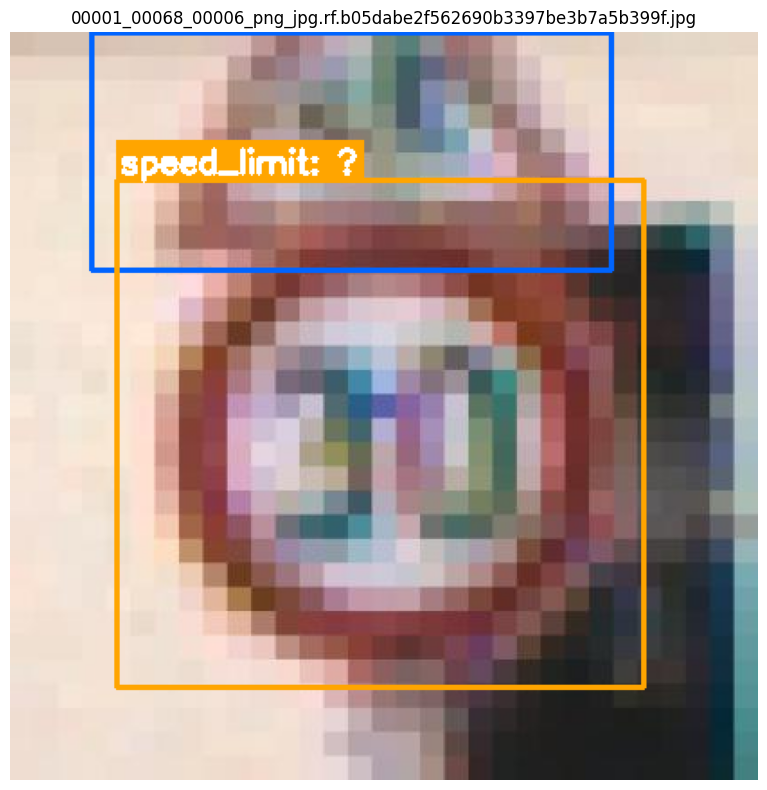

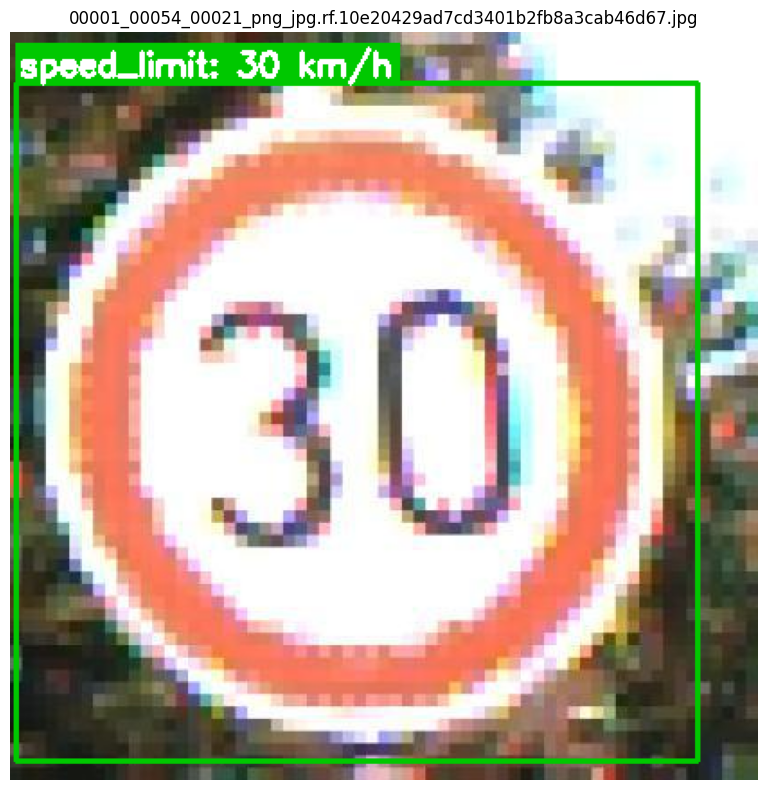

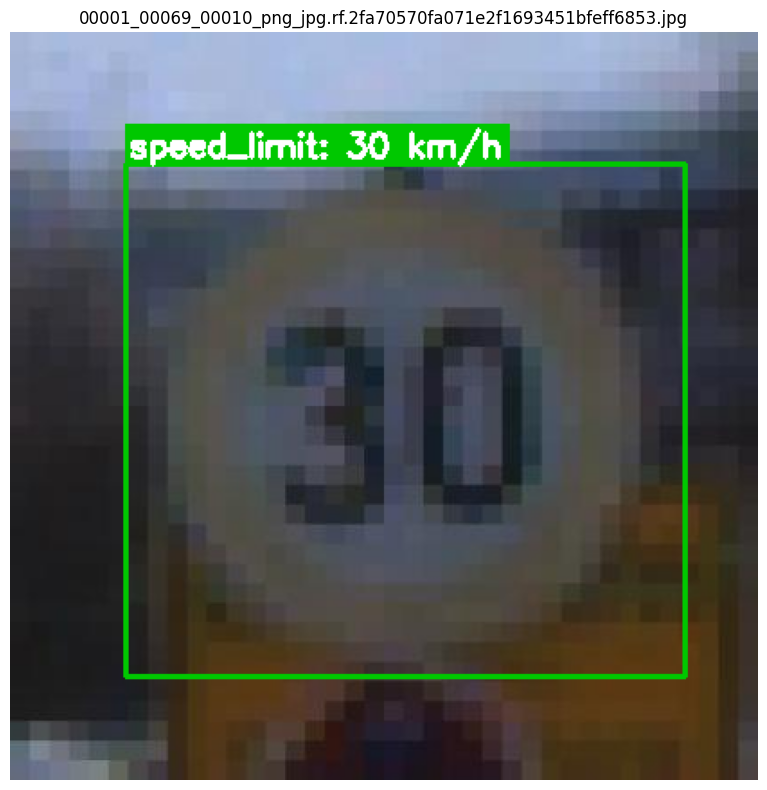

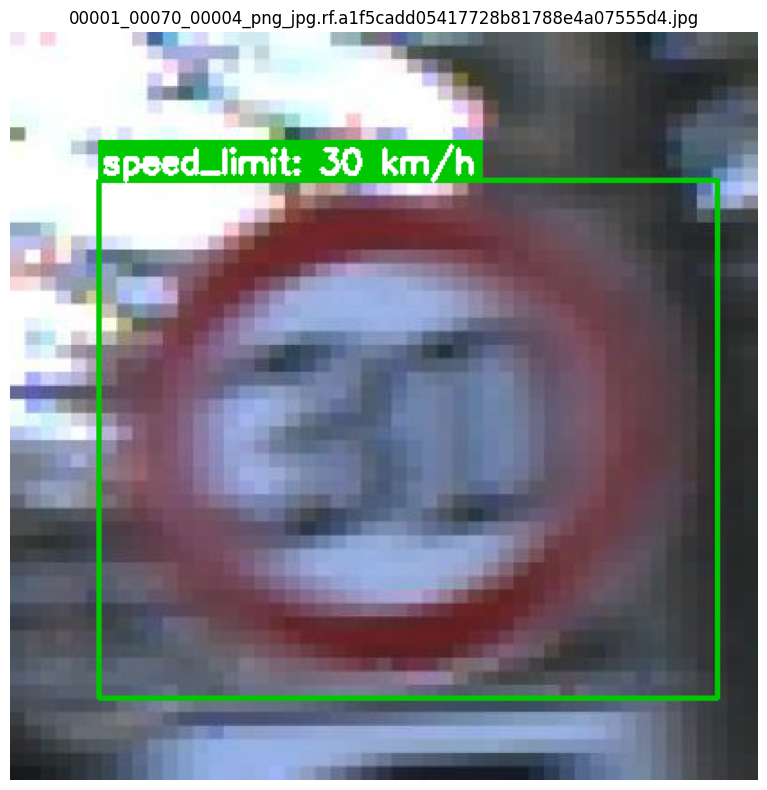

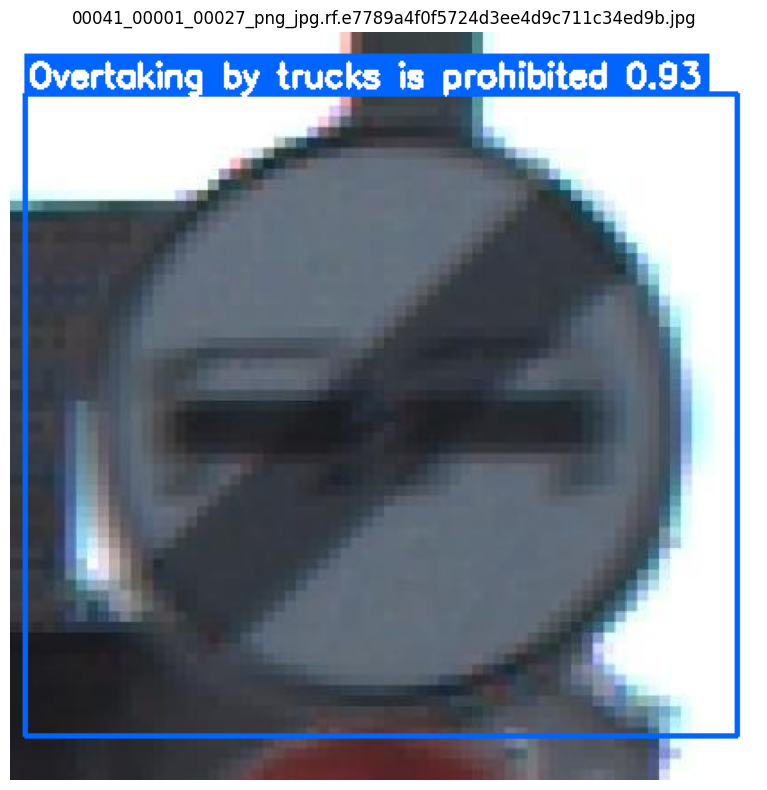

In [35]:
import random

test_image_dir = DATASET_DIR / "test" / "images"
test_images = list(test_image_dir.glob("*"))

samples = random.sample(test_images, 5)
for img_path in samples:
    run_pipeline(img_path)